# Error Analysis: K-Means

- **Question:** Can we clearly separate predictions vs non-predictions based on embeddings alone?

In [1]:
import os
import sys

import pandas as pd

notebook_dir = os.getcwd()

sys.path.append(os.path.join(notebook_dir, '../'))

from data_processing import DataProcessing
from data_visualizing import DataVisualizing

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_columns', 40)
# pd.set_option('display.max_rows', None)

## Load Data

In [3]:
base_data_path = DataProcessing.load_base_data_path(notebook_dir)
# combine_data_path = os.path.join(base_data_path, 'financial_phrase_bank/combined_generated_fin_phrase_bank')
train_data = os.path.join(base_data_path, 'classification_results/train_synthetic-v1_2026-03-23/seed3')

In [4]:
# model_results_path = os.path.join(combine_data_path, 'inference_chronicle2050_2026-03-07_21-51-47.csv')
test_data = os.path.join(train_data, 'external_fpb-maya-binary-imbalanced-96d-v1/', 'ml_classifiers_fpb-maya-binary-imbalanced-96d-v1.csv')

model_results_df = DataProcessing.load_from_file(test_data, 'csv', sep=',')
cols_to_drop = ["Dataset Name", "Author Type", "maya_label"]
compare_y_vs_yhats_df = DataProcessing.drop_df_columns(model_results_df, cols_to_drop)
compare_y_vs_yhats_df.head(3)

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,With the new production plant the company would increase its capacity to meet the expected increase in demand and would improve the use of raw materials and therefore increase the production profitability .,1,[-1.22568220e-01 2.48624131e-01 -4.82655168e-02 -1.09789923e-01\n -8.58348906e-02 3.63291465e-02 -1.27964811e-02 7.17335939e-02\n -1.18364163e-01 2.27930522e+00 -3.32476139e-01 -1.46164745e-02\n 1.25499114e-01 7.25146085e-02 6.57393187e-02 -5.76901138e-02\n -2.05907249e-03 1.51917112e+00 -3.29480022e-01 -4.57408801e-02\n 2.22120117e-02 1.05339624e-01 -4.22692373e-02 -1.23566784e-01\n -5.79119613e-03 6.18153140e-02 -5.48806489e-02 2.96797305e-02\n -1.07008472e-01 -9.98812243e-02 -9.39770564e-02 3.87728140e-02\n -5.82127571e-02 7.14930072e-02 9.65250358e-02 -3.75642404e-02\n 7.18023349e-03 6.21852428e-02 7.68979266e-02 -1.69069305e-01\n 1.44475931e-03 7.71993026e-02 3.41709815e-02 -1.10992551e-01\n -1.81387588e-02 -8.61631632e-02 -2.34903637e-02 6.00658916e-02\n -3....,1,1,1,1,0,1,1,1,1
1,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth in the range of 20 % -40 % with an operating profit margin of 10 % -20 % of net sales .",1,[-2.63320029e-01 3.28540474e-01 4.48558182e-02 -1.09422831e-02\n 3.39385755e-02 -1.25387803e-01 2.09340192e-02 8.32975954e-02\n 1.10356383e-01 1.74510765e+00 -3.98153275e-01 1.41264707e-01\n -8.98099765e-02 -1.47727029e-02 5.77163734e-02 -5.09223454e-02\n -4.27257568e-02 1.41277170e+00 -2.09747717e-01 1.56779997e-02\n -3.64826852e-03 5.97854443e-02 -7.89400712e-02 -1.39893517e-02\n 1.13595366e-01 9.83026922e-02 -5.14178127e-02 7.06899390e-02\n 2.47105230e-02 1.06609218e-01 -4.19648038e-03 -1.85196903e-02\n -1.48957130e-02 9.90139246e-02 1.10973224e-01 -2.59710420e-02\n -6.08825274e-02 4.48305123e-02 4.36691009e-02 -9.27021950e-02\n 6.36729002e-02 1.98753644e-02 2.10891932e-01 -8.54000822e-02\n 4.67465706e-02 -2.04764325e-02 -3.69948000e-02 1.16207667e-01\n 1....,1,1,0,0,1,1,1,0,1
2,TeliaSonera TLSN said the offer is in line with its strategy to increase its ownership in core business holdings and would strengthen Eesti Telekom 's offering to its customers .,1,[ 1.15080299e-02 1.98225155e-01 1.95062440e-02 -5.97744621e-02\n 1.75585955e-01 -1.25474662e-01 -3.72287892e-02 -2.83286646e-02\n -3.56662273e-02 1.96045303e+00 -2.79843062e-01 -1.04898110e-01\n 4.49508205e-02 1.31481076e-02 6.55795187e-02 -4.11130209e-03\n -5.56710083e-03 1.11790729e+00 -1.21459611e-01 -9.75316912e-02\n 2.18506586e-02 1.38311490e-01 9.17155594e-02 -5.85136563e-02\n 1.03342809e-01 7.32071251e-02 -3.92427929e-02 1.13294438e-01\n -1.07247204e-01 5.58346435e-02 -9.28281173e-02 5.48683619e-03\n -1.84886660e-02 5.24056628e-02 4.05881368e-02 -8.35432187e-02\n 1.13391867e-02 2.78038122e-02 -5.44880610e-03 -1.02035753e-01\n -6.69988245e-02 7.79658780e-02 5.37769347e-02 -1.39616817e-01\n 2.96867881e-02 1.13102477e-02 -3.53476144e-02 -1.88835058e-02\n -4....,1,1,1,1,1,1,1,1,1


In [5]:
if "Sentence Label" in compare_y_vs_yhats_df.columns:
    print(True)

True


## Plot Clusters

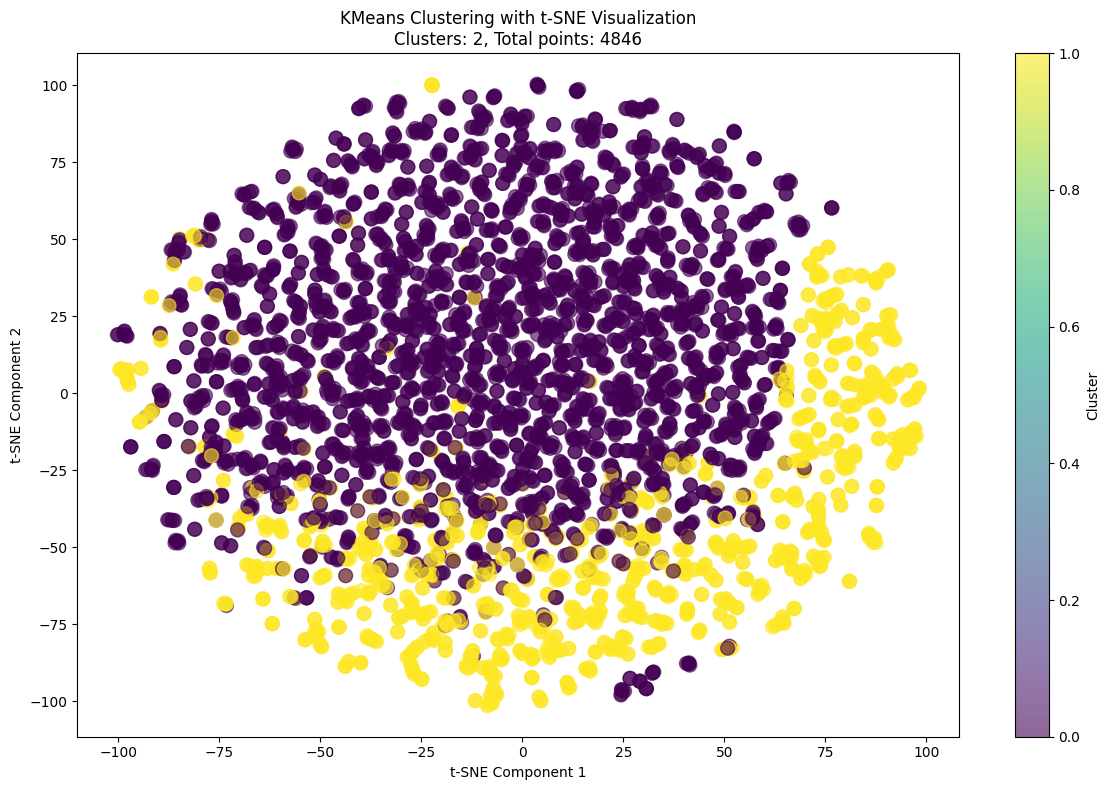


--- Sample Sentences Per Cluster ---

Cluster 0 (3515 sentences):
  Label 0 (Non-Prediction): 3137 sentences (89.2%)
  Label 1 (Prediction): 378 sentences (10.8%)

  Sample Sentences:
  - [0] The Internal Revenue Service sees about 20 percent of all taxpayers wait until the last two weeks to file , with about 40 million returns filed in April .
  - [0] Production is scheduled to start by the end of April 2007 .
  - [0] The decision means temporary lay-offs of fixed duration at the company 's Nastola and Jyvaskyla units , in southern and central Finland , respectively .
  - [0] The company 's board of directors has proposed a dividend of EUR0 .12 per share for 2006 .
  - [0] An individual promotion also generated slightly higher-than-expected revenues .
  - [0] The company 's market share is continued to increase further .
  - [0] Nokia said the outcome was a `` fair and responsible social plan . ''

Cluster 1 (1331 sentences):
  Label 0 (Non-Prediction): 1251 sentences (94.0%)
  Label

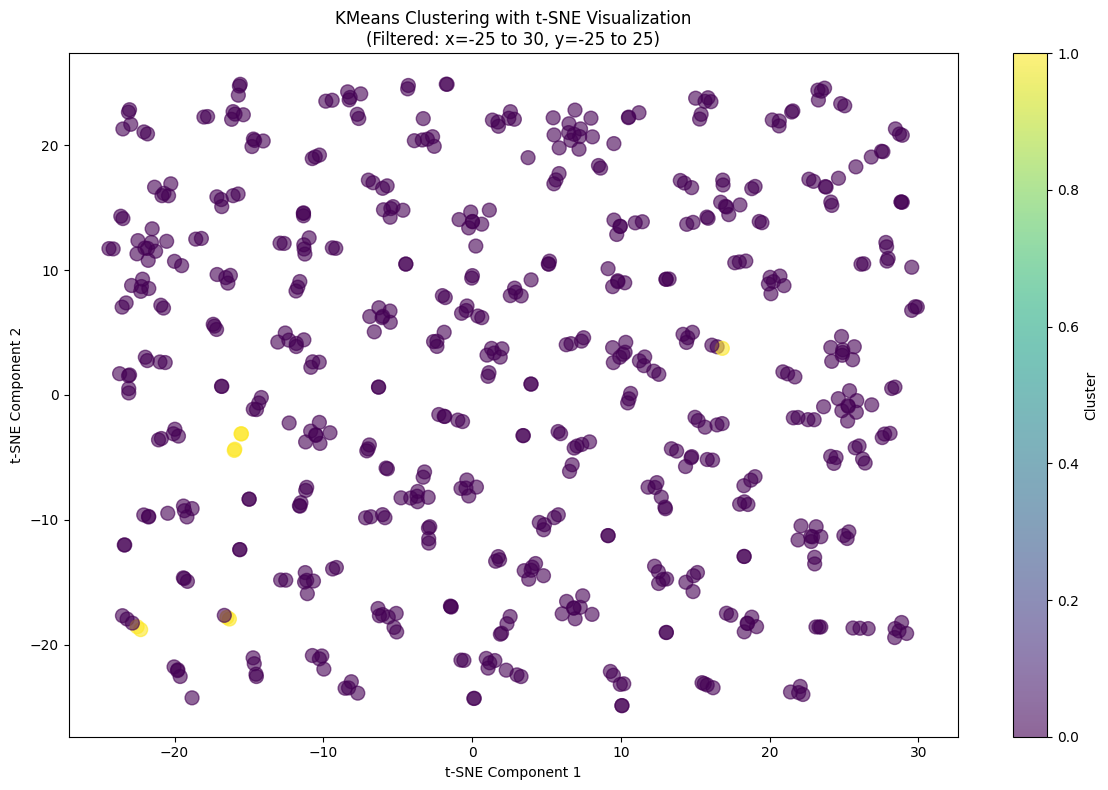


Filtered points: 599 out of 4846

--- Sample Sentences Per Cluster ---

Cluster 0 (590 sentences):
  Label 0 (Non-Prediction): 511 sentences (86.6%)
  Label 1 (Prediction): 79 sentences (13.4%)

  Sample Sentences:
  - [0] The layoff talks were first announced in August .
  - [0] `` The rest of this week 's tapings of Jimmy Kimmel Live have been canceled until he is back on his feet .
  - [0] According to him , construction work will start in spring 2007 , and the facility is to be commissioned in spring 2008 .
  - [0] Nevertheless , Fitch notes that the business fundamentals of the three banks currently remain sound .
  - [0] If Honkarakenne starts production there , it will need a partner for sawmill operations .
  - [0] According to Finnish petrol station chain St1 's managing director Kim Wiio , the company was forced to make purchases with rising prices in the first half of 2008 , and now consumer prices are going down almost daily due to competition .
  - [0] `` The new unit is 

,Base Sentence,Sentence Label,Base Sentence Embedding,perceptron,sgd_classifier,logistic_regression,ridge_classifier,decision_tree_classifier,random_forest_classifier,gradient_boosting_classifier,support_vector_machine_classifier,x_gradient_boosting_classifier
0,"The company still expects its turnover in 2010 to slightly increase from the level of 2009 , adding that `` market predictability is still too poor for trustworthy forecasts on the market development of the contract manufacturing business during the current year '' .",1,[-8.01109150e-02 2.36596152e-01 -5.08406200e-02 -5.91967329e-02\n 1.04830541e-01 -5.57341538e-02 4.63002734e-02 -7.99793098e-03\n 5.00161909e-02 2.16003442e+00 -3.25830907e-01 2.72772126e-02\n 5.99916726e-02 1.59362443e-02 1.50682740e-02 -5.99768125e-02\n -1.86955407e-02 1.20505536e+00 -1.61679640e-01 1.29278451e-02\n -3.52653414e-02 5.66716231e-02 -3.63632105e-02 -4.16581444e-02\n 5.95455319e-02 3.71346623e-02 -6.23186417e-02 1.79463835e-03\n -2.88256933e-03 -1.53720388e-02 -5.81578352e-02 -7.17658624e-02\n -3.74988429e-02 2.30221506e-02 6.13667704e-02 3.28951925e-02\n -1.52889658e-02 6.45012781e-02 3.34747620e-02 -5.69144934e-02\n 4.21757735e-02 3.62184793e-02 7.59416893e-02 -5.81586622e-02\n 2.79461760e-02 -6.79485649e-02 -5.53069077e-02 -4.56502773e-02\n -6....,1,1,1,1,0,1,1,1,1
1,The acquisition will considerably increase Kemira 's sales and market position in the Russian metal industry coatings market .,1,[-1.40268207e-01 2.62877226e-01 7.93231372e-03 8.86395387e-03\n 1.33090064e-01 -1.39466971e-01 -3.46719511e-02 3.12540419e-02\n -1.35381594e-02 1.94855237e+00 -3.55075836e-01 -5.88611923e-02\n 1.07916631e-01 -1.01686619e-01 7.30645880e-02 -2.87176911e-02\n 7.84564763e-02 1.41555691e+00 -2.05467880e-01 1.11137405e-02\n 6.38890564e-02 4.91101183e-02 -3.80713530e-02 -2.13202432e-01\n 1.53977945e-02 1.16409265e-01 -8.72310102e-02 1.10443465e-01\n -1.49720788e-01 -1.11090122e-02 -1.13384956e-02 -2.72994228e-02\n -4.55622422e-03 1.11839272e-01 1.43418118e-01 -1.77296344e-02\n 9.79520380e-02 2.71633500e-03 1.36354595e-01 -9.91588011e-02\n 6.38762265e-02 -4.63984534e-03 8.94726366e-02 -1.16808668e-01\n -1.94695797e-02 -7.92093202e-02 -5.76880984e-02 -1.53986409e-01\n -1....,1,1,1,1,1,1,1,1,1
2,The European Central Bank ECB is anticipated to raise its benchmark interest rate in the second half of 2011 at the earliest .,1,[-1.20699584e-01 1.79873049e-01 1.73853408e-03 -5.45859970e-02\n 5.89449145e-02 -1.04204759e-01 -1.60889160e-02 9.44252219e-03\n 3.99491787e-02 2.10684967e+00 -3.43668222e-01 1.20055210e-02\n 2.63054520e-01 4.43487726e-02 1.24486543e-01 -7.14907050e-02\n -1.25833079e-01 1.16267920e+00 -2.13971958e-02 -1.38778120e-01\n -1.31089548e-02 1.05435736e-02 2.13385839e-02 -8.12640265e-02\n 2.81560477e-02 9.61189270e-02 -1.85360424e-02 6.35134950e-02\n -1.40357837e-01 1.86843410e-01 6.95272610e-02 8.22113901e-02\n 1.08820073e-01 9.02375206e-02 4.24344763e-02 6.60759583e-02\n -7.42547512e-02 8.05179998e-02 2.79325497e-04 -4.35905680e-02\n 5.85857332e-02 1.05921350e-01 2.91262940e-02 -7.84882307e-02\n 1.27709866e-01 -1.84414592e-02 5.84357306e-02 -1.14396222e-01\n -6....,1,1,1,1,1,0,0,1,1
3,"In addition to fireplace exports , demand for lining stone has exceeded the level of the earlier part of the year and will continue to be clearly brisker for the remainder of the year .",1,[ 3.47433761e-02 1.48696184e-01 -5.46568073e-02 -6.14089146e-02\n 1.80230718e-02 -8.22572932e-02 4.08355035e-02 5.94800338e-02\n -2.00382550e-03 2.21422362e+00 -2.03467265e-01 3.70283425e-02\n 5.76656535e-02 -7.71550555e-03 -1.87408156e-03 -6.36181682e-02\n -2.15582689e-03 1.15881896e+00 -2.05967009e-01 -3.01147792e-02\n -9.24080834e-02 -2.25987728e-03 -4.76512760e-02 -1.82040278e-02\n 4.62916447e-03 1.50740556e-02 -1.14114687e-01 -1.26609229e-03\n -1.55915782e-01 4.60063666e-02 -1.12252170e-02 2.28079129e-02\n -4.83404174e-02 1.29099384e-01 1.19156674e-01 -7.49192685e-02\n -6.22809753e-02 1.54491989e-02 9.48030651e-02 -2.9890

In [6]:
DataVisualizing.plot_kmeans_tsne(
    df=compare_y_vs_yhats_df,
    text_column='Base Sentence',
    embedding_col_name="Base Sentence Embedding",
    n_clusters=2,
    show_sentences_per_cluster=7,
    sentence_label='Sentence Label',
    filter_x_axis=[-25, 30],
    filter_y_axis=[-25, 25]
    )

## Takeaways

1. Since imbalanced data set (90.5% non-predictions and 9.5% predictions), the skewness of non-predictions to predictions for each cluster is valid.
2. Visually, the embeddings, are somewhat linearly separable because majority of the purple are above and majority of the yellow are below, which suggests embeddings capture some underlying semantic structure, but further sentence-level analysis is needed to determine whether that structure corresponds to the prediction/non-prediction distinction.
3. Embeddings alone are not enough, so need futher analyses at sentence-level.
